In [1]:
import os
import csv
import random

os.environ["KERAS_BACKEND"] = "tensorflow"  # @param ["tensorflow", "jax", "torch"]

import keras
from keras import layers
from keras import ops
import tensorflow as tf

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image,ImageDraw,ImageFont

import unicode

2024-09-26 16:26:15.278201: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-26 16:26:15.289783: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-09-26 16:26:15.293447: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-09-26 16:26:15.301874: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-09-26 16:26:16.483022: W tensorflow/compiler/tf2

In [2]:
# https://stackoverflow.com/questions/47948821/python-imagefont-and-imagedraw-check-font-for-character-support

DATA_SIZE = 8000

SAVE_DIR = "/root/Data/hangul/weights"
WEIGHT_FILE = SAVE_DIR + "/ASC_2.weights.h5"
VALID_DATA_SIZE = DATA_SIZE / 2

input_shape = (64, 64, 3)

learning_rate = 0.001 / 38#30#/ 10# / 12 #/ 10# / 4
weight_decay = 0.0001 / 5 #/ 2#/2#/ 4
batch_size = 256
num_epochs = 400  # For real training, use num_epochs=100. 10 is a test value
image_size = 64  # We'll resize input images to this size
patch_size = 8 #8  # Size of the patches to be extract from the input images
num_patches = (image_size // patch_size) ** 2
projection_dim = 64
num_heads = 4
transformer_units = [
    projection_dim * 2,
    projection_dim,
]  # Size of the transformer layers
transformer_layers = 8
mlp_head_units = [
    1560,
    1280,
]  # Size of the dense layers of the final classifier

In [3]:
ja2label = {'ㄱ':0, 'ㄲ':1, 'ㄴ':2, 'ㄷ':3, 'ㄸ':4, 'ㄹ':5, 'ㅁ':6, 'ㅂ':7, 'ㅃ':8,
'ㅅ':9, 'ㅆ':10, 'ㅇ':11,  'ㅈ':12, 'ㅉ':13, 'ㅊ':14, 'ㅋ':15, 'ㅌ':16,  'ㅍ':17, 'ㅎ':18}

mo2label = {'ㅏ':0, 'ㅐ':1, 'ㅑ':2, 'ㅒ':3, 'ㅓ':4, 'ㅔ':5, 'ㅕ':6, 'ㅖ':7, 'ㅗ':8, 'ㅘ':9, 
'ㅙ':10, 'ㅚ':11, 'ㅛ':12, 'ㅜ':13, 'ㅝ':14, 'ㅞ':15, 'ㅟ':16, 'ㅠ':17, 'ㅡ':18, 'ㅢ':19, 'ㅣ':20}

ba2label = {None:0, 'ㄱ':1, 'ㄲ':2, 'ㄳ':3, 'ㄴ':4, 'ㄵ':5, 'ㄶ':6, 'ㄷ':7, 'ㄹ':8, 'ㄺ':9,
'ㄻ':10, 'ㄼ':11, 'ㄽ':12, 'ㄾ':13, 'ㄿ':14, 'ㅀ':15, 'ㅁ':16, 'ㅂ':17, 'ㅄ':18, 'ㅅ':19,
'ㅆ':20, 'ㅇ':21, 'ㅈ':22, 'ㅊ':23, 'ㅋ':24, 'ㅌ':25, 'ㅍ':26, 'ㅎ':27}

label2ja = {0: 'ㄱ', 1: 'ㄲ', 2: 'ㄴ', 3: 'ㄷ', 4: 'ㄸ', 5: 'ㄹ',
            6: 'ㅁ', 7: 'ㅂ', 8: 'ㅃ', 9: 'ㅅ', 10: 'ㅆ', 11: 'ㅇ',
            12: 'ㅈ', 13: 'ㅉ', 14: 'ㅊ', 15: 'ㅋ', 16: 'ㅌ', 17: 'ㅍ', 18: 'ㅎ'}

label2mo = {0: 'ㅏ', 1: 'ㅐ', 2: 'ㅑ', 3: 'ㅒ', 4: 'ㅓ', 5: 'ㅔ',
            6: 'ㅕ', 7: 'ㅖ', 8: 'ㅗ', 9: 'ㅘ', 10: 'ㅙ', 11: 'ㅚ',
            12: 'ㅛ', 13: 'ㅜ', 14: 'ㅝ', 15: 'ㅞ', 16: 'ㅟ', 17: 'ㅠ',
            18: 'ㅡ', 19: 'ㅢ', 20: 'ㅣ'}

label2ba = {0: None, 1: 'ㄱ', 2: 'ㄲ', 3: 'ㄳ', 4: 'ㄴ', 5: 'ㄵ',
            6: 'ㄶ', 7: 'ㄷ', 8: 'ㄹ', 9: 'ㄺ', 10: 'ㄻ', 11: 'ㄼ',
            12: 'ㄽ', 13: 'ㄾ', 14: 'ㄿ', 15: 'ㅀ', 16: 'ㅁ', 17: 'ㅂ',
            18: 'ㅄ', 19: 'ㅅ', 20: 'ㅆ', 21: 'ㅇ', 22: 'ㅈ', 23: 'ㅊ',
            24: 'ㅋ', 25: 'ㅌ', 26: 'ㅍ', 27: 'ㅎ'}

ASC2label = {'0' : 0, '1': 1, '2' : 2, '3' : 3, '4' : 4, '5' : 5, '6' : 6, '7' : 7, '8' : 8, '9' : 9,
             'A' : 10, 'B': 11, 'C' : 12, 'D' : 13, 'E' : 14, 'F' : 15, 'G' : 16, 'H' : 17, 'I' : 18, 'J' : 19, 'K' : 20, 'L' : 21, 'M' : 22,
             'N' : 23, 'O': 24, 'P' : 25, 'Q' : 26, 'R' : 27, 'S' : 28, 'T' : 29, 'U' : 30, 'V' : 31, 'W' : 32, 'X' : 33, 'Y' : 34, 'Z' : 35,
             'a' : 36, 'b': 37, 'c' : 38, 'd' : 39, 'e' : 40, 'f' : 41, 'g' : 42, 'h' : 43, 'i' : 44, 'j' : 45, 'k' : 46, 'l' : 47, 'm' : 48,
             'n' : 49, 'o': 50, 'p' : 51, 'q' : 52, 'r' : 53, 's' : 54, 't' : 55, 'u' : 56, 'v' : 57, 'w' : 58, 'x' : 59, 'y' : 60, 'z' : 61,
             ':' : 62, '#': 63, '@' : 64, '(' : 65, ')' : 66, '-' : 67}

label2ASC = {0 : '0', 1 : '1', 2 : '2', 3 : '3', 4 : '4', 5 : '5', 6 : '6', 7 : '7', 8 : '8', 9 : '9',
             10 : 'A', 11 : 'B', 12 : 'C', 13 : 'D', 14 : 'E', 15 : 'F', 16 : 'G', 17 : 'H', 18 : 'I', 19 : 'J', 20 : 'K', 21: 'L', 22 :'M',
             23 : 'N', 24 : 'O', 25 : 'P', 26 : 'Q', 27 : 'R', 28 : 'S', 29 : 'T', 30 :'U', 31: 'V', 32 : 'W', 33 : 'X', 34 : 'Y', 35 : 'Z',
             36 : 'a', 37 : 'b', 38 : 'c', 39 : 'd', 40 : 'e', 41 : 'f', 42 : 'g', 43 : 'h', 44 : 'i', 45 : 'j', 46 : 'k', 47 : 'l', 48 : 'm',
             49 : 'n', 50 : 'o', 51 : 'p', 52 : 'q', 53 : 'r', 54 : 's', 55 : 't', 56 : 'u', 57 : 'v', 58 : 'w', 59 : 'x', 60 : 'y', 61 : 'z',
             62 : ':', 63 : '#', 64 : '@', 65 : '(', 66 : ')', 67 : '-'
             }

In [4]:
from IPython.display import clear_output
import shutil

def Dedup(baseDir):
    dtFile = baseDir + "/" + "FullPath.csv"
    outFile = baseDir + "/" + "flt.csv"
    
    csvFile = open(dtFile, 'r', encoding='utf-8')
    reader = csv.reader(csvFile)
    
    f = open(outFile, "w", encoding='utf-8')
    writer = csv.writer(f)
    
    for line in reader:
        imgFile = line[0]
        
        if os.path.exists(imgFile):
            writer.writerow(line)
    
    csvFile.close()
    f.close()
    
def MergeDataset(baseDir, outPath = ""):
    cmdString = "cat"
    commonFileName = 'flt.csv'
    for file in baseDir:
        cmdString = cmdString + " " + file + "/" + commonFileName
    cmdString = cmdString + " > " + outPath
    
    print(cmdString)
    #os.system("cat text1.txt text2.text > merge.txt")
    os.system(cmdString)
    
datasetList = ['/mnt/d/linData/synth_asc1/train',
               '/mnt/d/linData/synth_asc3/train',
               '/mnt/d/linData/synth_asc4/train',
               '/mnt/d/linData/synth_asc5/train',
               '/mnt/d/linData/synth_asc6/train',
               '/mnt/d/linData/synth_asc7/train',
               '/mnt/d/linData/synth_asc8/train'
               ]
# datasetList = ['/mnt/d/linData/synth_asc4/train']
# 1148389
# 1131637
# 1125598
# 1325598
# 1325598
# 1318963
# 1298474

#Dedup('/mnt/d/linData/synth_asc3/train')
# Dedup('/mnt/d/linData/synth_asc4/train')
# Dedup('/mnt/d/linData/synth_asc5/train')
# Dedup('/mnt/d/linData/synth_asc6/train')
# Dedup('/mnt/d/linData/synth_asc7/train')
#Dedup('/mnt/d/linData/synth_asc4/train')

#MergeDataset(datasetList, "/root/Data/hangul/dataset/ASC_train.csv")

cat /mnt/d/linData/synth_asc1/train/flt.csv /mnt/d/linData/synth_asc3/train/flt.csv /mnt/d/linData/synth_asc4/train/flt.csv /mnt/d/linData/synth_asc5/train/flt.csv /mnt/d/linData/synth_asc6/train/flt.csv /mnt/d/linData/synth_asc7/train/flt.csv /mnt/d/linData/synth_asc8/train/flt.csv > /root/Data/hangul/dataset/ASC_train.csv


In [5]:
def getSpecificExtensionFiles(path, extension):
    out = []
    for (path, dir, files) in os.walk(path):
        for filename in files:
            ext = os.path.splitext(filename)[-1]
            if ext == extension:
                #print("%s/%s" % (path, filename))
                out.append(path + "/" + filename)
    return out

def CreateFontImage(str, fontPath):
    font = ImageFont.truetype(fontPath, 28, encoding = 'utf-8')
    left, top, right, bottom = font.getbbox(str)
    width = right - left
    height = bottom - top
    
    canvas = Image.new('RGB', (width + 10, height + 14), "white")
    draw = ImageDraw.Draw(canvas)
    draw.text((3,3), str, 'black', font)
    
    img = canvas.resize((64,64))

    img = tf.image.convert_image_dtype(img, tf.float32)
    img = np.array(img)
    img = np.expand_dims(img, axis=0)
    
    return img

def GetAsciiCharImage(fontPath):
    idx = random.randrange(0, len(ASC2label))
    char = label2ASC[idx]
    
    label = np.expand_dims(np.array(idx), axis = 0)
    
    return CreateFontImage(char, fontPath), (label)

def getFontImage(fontPath, imageNum):
    cho = random.randrange(0, 19)
    jung = random.randrange(0, 21)
    jong = random.randrange(0, 28)
    
    ja = label2ja[cho]
    mo = label2mo[jung]
    ba = label2ba[jong]

    char = unicode.join_jamos_char(ja, mo ,ba)
    
    label1 = np.expand_dims(np.array(cho), axis=0)
    label2 = np.expand_dims(np.array(jung), axis=0)
    label3 = np.expand_dims(np.array(jong), axis=0)
    
    return CreateFontImage(char, fontPath), (label1, label2, label3)

In [6]:
def get_dataset_fromCsv():
    cnt = 0
    
    #fontFiles = getSpecificExtensionFiles("/root/Data/font/clova-all", ".ttf")
    fontFiles = getSpecificExtensionFiles("/root/venv/project/synthtiger/resources/font", ".ttf")
    fontNum = len(fontFiles)
    
    os.system("shuf /root/Data/hangul/dataset/ASC_train.csv > /root/Data/hangul/dataset/ASC_train_shuffle.csv")
    
    csvFile = open("/root/Data/hangul/dataset/ASC_train_shuffle.csv", 'r', encoding='utf-8')
    #csvFile = open("/root/Data/hangul/dataset/test.csv", 'r', encoding='utf-8')
    reader = csv.reader(csvFile)
    
    for line in reader:
        imgFile = line[0]
        
        if not os.path.exists(imgFile):
            continue

        img = Image.open(imgFile)
        img = img.resize((64,64))
        
        img = tf.image.convert_image_dtype(img, tf.float32)
        img = np.array(img)
        img = np.expand_dims(img, axis=0)
        
        label1 = np.expand_dims(np.array(int(line[1])), axis=0)
        
        yield img, (label1)
        
        fontidx = random.randrange(0, fontNum)
        yield GetAsciiCharImage(fontFiles[fontidx])

        if (cnt > DATA_SIZE): break
        else                : cnt += 1

        
        
def get_valid_dataset_fromCsv():
    cnt = 0
    
    fontFiles = getSpecificExtensionFiles("/root/venv/project/synthtiger/resources/font", ".ttf")
    fontNum = len(fontFiles)

    os.system("shuf /root/Data/hangul/dataset/ASC_valid.csv > /root/Data/hangul/dataset/ASC_valid_shuffle.csv")    
    csvFile = open("/root/Data/hangul/dataset/ASC_valid_shuffle.csv", 'r', encoding='utf-8')
    #csvFile = open("/root/Data/hangul/dataset/shuffled_tranDataset.csv", 'r', encoding='utf-8')
    reader = csv.reader(csvFile)
    
    for line in reader:
        imgFile = line[0]
        
        if not os.path.exists(imgFile):
            continue

        img = Image.open(imgFile)
        img = img.resize((64,64))
        
        img = tf.image.convert_image_dtype(img, tf.float32)
        img = np.array(img)
        img = np.expand_dims(img, axis=0)
        
        label1 = np.expand_dims(np.array(int(line[1])), axis=0)
                
        yield img, (label1)
        
        fontidx = random.randrange(0, fontNum)
        yield GetAsciiCharImage(fontFiles[fontidx])

        if (cnt > VALID_DATA_SIZE): 
            break
        else                : cnt += 1

In [7]:
train_dataset = tf.data.Dataset.from_generator(get_dataset_fromCsv,
                                            output_signature=
                                            (
                                            tf.TensorSpec(shape = (None, 64, 64, 3), dtype =tf.float32, name = "posts"),
                                            (tf.TensorSpec(shape = (1,), dtype = tf.int64, name = "out"))
                                            )
                                            #output_shapes=([19,21,28])
                                            )


valid_dataset = tf.data.Dataset.from_generator(get_valid_dataset_fromCsv,
                                            output_signature=
                                            (
                                            tf.TensorSpec(shape = (None, 64, 64, 3), dtype =tf.float32, name = "posts"),
                                            (tf.TensorSpec(shape = (1,), dtype = tf.int64, name = "out"))
                                            )
                                            #output_shapes=([19,21,28])
                                            )

I0000 00:00:1727335579.765717 2280654 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1727335579.811077 2280654 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1727335579.811126 2280654 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1727335579.813081 2280654 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1727335579.813121 2280654 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

In [8]:
# data_augmentation = keras.Sequential(
#     [
#         layers.Normalization(),
#         layers.Resizing(image_size, image_size),
#         layers.RandomFlip("horizontal"),
#         layers.RandomRotation(factor=0.02),
#         layers.RandomZoom(height_factor=0.2, width_factor=0.2),
#     ],
#     name="data_augmentation",
# )
# # Compute the mean and the variance of the training data for normalization.
# data_augmentation.layers[0].adapt(x_train)


"""
## Implement multilayer perceptron (MLP)
"""
def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=keras.activations.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x


"""
## Implement patch creation as a layer
"""
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        input_shape = ops.shape(images)
        batch_size = input_shape[0]
        height = input_shape[1]
        width = input_shape[2]
        channels = input_shape[3]
        num_patches_h = height // self.patch_size
        num_patches_w = width // self.patch_size
        patches = keras.ops.image.extract_patches(images, size=self.patch_size)
        patches = ops.reshape(
            patches,
            (
                batch_size,
                num_patches_h * num_patches_w,
                self.patch_size * self.patch_size * channels,
            ),
        )
        return patches

    def get_config(self):
        config = super().get_config()
        config.update({"patch_size": self.patch_size})
        return config
    



In [9]:
def ShowBatchImage():
    testImage = "/root/Data/hangul_handwrite_val/image/test/26.jpg"
    testImage = "/mnt/d/linData/synth3/train/images/8/80002.jpg"
    plt.figure(figsize=(4, 4))
    image = tf.io.read_file(testImage)
    image = tf.image.decode_jpeg(image, channels=3)
    
    image = CreateFontImage("한", "/root/Data/font/clova-all/가람연꽃/나눔손글씨_가람연꽃.ttf")
    plt.imshow(image)
    plt.axis("off")

    resized_image = ops.image.resize(
        ops.convert_to_tensor([image]), size=(image_size, image_size)
    )
    
    resized_image = tf.image.convert_image_dtype(resized_image, tf.float32)
    patches = Patches(patch_size)(resized_image)
    print(f"Image size: {image_size} X {image_size}")
    print(f"Patch size: {patch_size} X {patch_size}")
    print(f"Patches per image: {patches.shape[1]}")
    print(f"Elements per patch: {patches.shape[-1]}")

    n = int(np.sqrt(patches.shape[1]))
    plt.figure(figsize=(4, 4))
    for i, patch in enumerate(patches[0]):
        ax = plt.subplot(n, n, i + 1)
        patch_img = ops.reshape(patch, (patch_size, patch_size, 3))
        plt.imshow(ops.convert_to_numpy(patch_img).astype("uint8"))
        plt.axis("off")
        
#ShowBatchImage()

In [10]:
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = ops.expand_dims(
            ops.arange(start=0, stop=self.num_patches, step=1), axis=0
        )
        projected_patches = self.projection(patch)
        encoded = projected_patches + self.position_embedding(positions)
        return encoded

    def get_config(self):
        config = super().get_config()
        config.update({"num_patches": self.num_patches})
        return config



In [11]:
def create_vit_classifier():
    inputs = keras.Input(shape=input_shape, name='posts')
    # Augment data.
    #augmented = data_augmentation(inputs)
    # Create patches.
    patches = Patches(patch_size)(inputs)
    # Encode patches.
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)
    print("Num Pathces : ", num_patches)
    print("projection_dim : ", projection_dim)
    
    # Create multiple layers of the Transformer block.
    for _ in range(transformer_layers):
        # Layer normalization 1.
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        # Create a multi-head attention layer.
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim, dropout=0.1
        )(x1, x1)
        # Skip connection 1.
        x2 = layers.Add()([attention_output, encoded_patches])
        # Layer normalization 2.
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        # MLP.
        x3 = mlp(x3, hidden_units=transformer_units, dropout_rate=0.1)
        # Skip connection 2.
        encoded_patches = layers.Add()([x3, x2])

    DropR = 0.10
    # Create a [batch_size, projection_dim] tensor.
    representation1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation1 = layers.Flatten()(representation1)
    representation1 = layers.Dropout(DropR)(representation1)
    
    # Add MLP.
    features1 = mlp(representation1, hidden_units=mlp_head_units, dropout_rate=DropR)
    # Classify outputs.
    logits1 = layers.Dense(len(ASC2label) + 1, name = "DenseCho2")(features1)
    # Create the Keras model.
    model = keras.Model(inputs=inputs, outputs=[logits1])
    return model

In [12]:
def run_experiment(model):
    optimizer = keras.optimizers.AdamW(
        learning_rate=learning_rate, weight_decay=weight_decay
    )
    
    losses = {
    "DenseCho2": "sparse_categorical_crossentropy",
    "DenseJung2": "sparse_categorical_crossentropy",
    "DenseJong2": "sparse_categorical_crossentropy"
    }

    model.compile(
        optimizer=optimizer,

        #loss=losses,
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=[
            keras.metrics.SparseCategoricalAccuracy(name="accuracy")
            #keras.metrics.SparseTopKCategoricalAccuracy(5, name="top-5-accuracy"),
        ],
    )
    checkPoint_path = WEIGHT_FILE
    
    #checkpoint_filepath = "/tmp/checkpoint.weights.h5"
    checkpoint_callback = keras.callbacks.ModelCheckpoint(
        checkPoint_path,
        monitor="val_loss", #val_loss
        save_best_only=True,
        save_weights_only=True,
    )
    
    #model.load_weights(WEIGHT_FILE)

    history = model.fit(
        train_dataset,
        batch_size=batch_size,
        epochs=num_epochs,
        #validation_split=0.1,
        callbacks=[checkpoint_callback],
        validation_data=valid_dataset
    )

    # model.load_weights(checkpoint_filepath)
    # _, accuracy, top_5_accuracy = model.evaluate(x_test, y_test)
    # print(f"Test accuracy: {round(accuracy * 100, 2)}%")
    # print(f"Test top 5 accuracy: {round(top_5_accuracy * 100, 2)}%")

    return history

In [13]:
vit_classifier = create_vit_classifier()
vit_classifier.summary()
vit_classifier.load_weights(WEIGHT_FILE)


Num Pathces :  64
projection_dim :  64


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ posts (InputLayer)  │ (None, 64, 64, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches (Patches)   │ (None, 64, 192)   │          0 │ posts[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder       │ (None, 64, 64)    │     16,448 │ patches[0][0]     │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 64, 64)    │        128 │ patch_encoder[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64)    │          0 │ multi_head_atten… │
│                     │                   │            │ patch_encoder[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 128)   │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64, 64)    │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64, 64)    │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 64)    │          0 │ dropout_2[0][0],  │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 64, 64)    │          0 │ multi_head_atten… │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64, 128)   │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64, 64)    │      8,256 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64, 64)    │          0 │ dense_4[0][0]   

 Total params: 9,159,965 (34.94 MB)

 Trainable params: 9,159,965 (34.94 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# https://stackoverflow.com/questions/59737875/keras-change-learning-rate
history = run_experiment(vit_classifier)

Epoch 1/400


I0000 00:00:1727335604.818942 2280830 service.cc:146] XLA service 0x7f94fc00cac0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1727335604.819938 2280830 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce GTX 1650, Compute Capability 7.5
2024-09-26 16:26:45.394118: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-09-26 16:26:47.395162: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907


      1/Unknown 47s 47s/step - accuracy: 0.0000e+00 - loss: 0.8415

I0000 00:00:1727335627.713536 2280830 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  16001/Unknown 416s 23ms/step - accuracy: 0.9264 - loss: 0.2164

...

16004/16004 ━━━━━━━━━━━━━━━━━━━━ 480s 30ms/step - accuracy: 0.9125 - loss: 0.2348 - val_accuracy: 0.9253 - val_loss: 0.2088
Epoch 6/400
16004/16004 ━━━━━━━━━━━━━━━━━━━━ 462s 29ms/step - accuracy: 0.9206 - loss: 0.2213 - val_accuracy: 0.9182 - val_loss: 0.2290
Epoch 7/400
16004/16004 ━━━━━━━━━━━━━━━━━━━━ 453s 28ms/step - accuracy: 0.9227 - loss: 0.2180 - val_accuracy: 0.9233 - val_loss: 0.2089
Epoch 8/400
16004/16004 ━━━━━━━━━━━━━━━━━━━━ 441s 28ms/step - accuracy: 0.9177 - loss: 0.2264 - val_accuracy: 0.9215 - val_loss: 0.2154
Epoch 9/400


2024-09-26 17:31:27.716295: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_2]]


16004/16004 ━━━━━━━━━━━━━━━━━━━━ 430s 27ms/step - accuracy: 0.9110 - loss: 0.2416 - val_accuracy: 0.9244 - val_loss: 0.2140
Epoch 10/400


2024-09-26 17:38:38.028714: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 3459670120919843264
2024-09-26 17:38:38.028809: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 16907883960622734692


16004/16004 ━━━━━━━━━━━━━━━━━━━━ 419s 26ms/step - accuracy: 0.9190 - loss: 0.2291 - val_accuracy: 0.9187 - val_loss: 0.2114
Epoch 11/400
16004/16004 ━━━━━━━━━━━━━━━━━━━━ 408s 25ms/step - accuracy: 0.9204 - loss: 0.2175 - val_accuracy: 0.9232 - val_loss: 0.2144
Epoch 12/400
16004/16004 ━━━━━━━━━━━━━━━━━━━━ 402s 25ms/step - accuracy: 0.9225 - loss: 0.2195 - val_accuracy: 0.9252 - val_loss: 0.2122
Epoch 13/400
16004/16004 ━━━━━━━━━━━━━━━━━━━━ 393s 25ms/step - accuracy: 0.9241 - loss: 0.2186 - val_accuracy: 0.9259 - val_loss: 0.2125
Epoch 14/400
 5898/16004 ━━━━━━━━━━━━━━━━━━━━ 2:59 18ms/step - accuracy: 0.9174 - loss: 0.2384

In [20]:
def ASC_data_filtering(csvFilePath, rmProb):
    numerator = rmProb
    denominator = 1
    
    shufFile = "./shuffled.csv"
    cmdString = "shuf " + csvFilePath + " > " + shufFile
    
    #os.system("shuf /root/Data/hangul/dataset/ASC_train.csv > /root/Data/hangul/dataset/ASC_train_shuffle.csv")
    os.system(cmdString)
    
    
    while numerator % 1 != 0 :
        numerator = numerator * 10
        denominator = denominator * 10
        
    # print("numerator : ", numerator, " | denominator : ", denominator) 
    
    csvFile = open(shufFile, 'r', encoding='utf-8')
    reader = csv.reader(csvFile)
    
    totalCnt = 0
    rmCnt = 0
    for line in reader:        
        imgFile = line[0]
        label = line[1]
        
        if not os.path.exists(imgFile):
            continue
        
        totalCnt += 1
        
        img = tf.io.read_file(imgFile)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.convert_image_dtype(img, tf.float32)
        img = tf.image.resize(img, (64, 64))
        
        img = np.array(img)
        img = np.expand_dims(img, axis=0)
        
        out = vit_classifier.predict(img)
        out = out.argmax()
        
        label_idx = int(label)
        
        if out != label_idx:
            #print("UNMATCHED, result : ",out, ", label : ",label_idx)
            randInt = random.choice(range(0, denominator))
            
            if out > label_idx:
                max = out
                min = label_idx
            else:
                max = label_idx
                min = out
                
            if max - 26 == min:
                continue
            
            # if max == 0 | 24 | 50 // 0 o O continue;
            if min == 0 and (max == 24 or max == 50):
                continue
            
            # 1 47 // 1 l
            
            if min == 1 and max == 47:
                continue
            
            # I 18 l 47 1 1
            
            if min == 18 and max == 47:
                continue
            
            # 9 42 // 9 g
            
            if min == 9 and max == 42:
                continue
            
            if randInt <= numerator:
                clear_output()
                
                image = Image.open(imgFile)
                image.show()
                
                rmCnt +=1
                # print("imgFile : ", imgFile)
                print("TotalCount : ", totalCnt)
                print("UNMATCHED, result : ",label2ASC[out], ", label : ",label2ASC[label_idx])
                print("Remove Image Coutn : ", rmCnt)
                
                os.remove(imgFile)
                #shutil.move(imgFile, '/mnt/d/linData/synth_asc4/train/tmp')
                
                print(imgFile, " has been deleted")
        
                
#"/mnt/d/linData/synth2/train/FullPathImageSynth2.csv"
#ASC_data_filtering('/mnt/d/linData/synth_asc4/train/FullPath.csv', 0.1)
#ASC_data_filtering('/mnt/d/linData/synth_asc5/train/FullPath.csv', 0.20)
#ASC_data_filtering('/mnt/d/linData/synth_asc4/train/flt.csv', 0.30)
#ASC_data_filtering('/root/Data/hangul_handwrite_val/image/ASC1', 0.075)

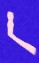

TotalCount :  255
UNMATCHED, result :  ( , label :  L
Remove Image Coutn :  5
/mnt/d/linData/synth_asc6/train/images/8/87277.jpg  has been deleted
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


KeyboardInterrupt: 

In [21]:
ASC_data_filtering('/mnt/d/linData/synth_asc6/train/flt.csv', 0.30)
#ASC_data_filtering('/mnt/d/linData/synth_asc2/train/flt.csv', 0.20)

In [14]:
from IPython.display import clear_output
import shutil

def ASC_data_filtering_mv(csvFilePath):
    baseDir = os.path.dirname(csvFilePath)

    shufFile = "./shuffled.csv"
    cmdString = "shuf " + csvFilePath + " > " + shufFile
    
    #os.system("shuf /root/Data/hangul/dataset/ASC_train.csv > /root/Data/hangul/dataset/ASC_train_shuffle.csv")
    os.system(cmdString)
    
    csvFile = open(shufFile, 'r', encoding='utf-8')
    reader = csv.reader(csvFile)
    
    totalCnt = 0
    rmCnt = 0
    for line in reader:        
        imgFile = line[0]
        label = line[1]
        
        if not os.path.exists(imgFile):
            continue
        
        totalCnt += 1
        
        img = tf.io.read_file(imgFile)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.convert_image_dtype(img, tf.float32)
        img = tf.image.resize(img, (64, 64))
        
        img = np.array(img)
        img = np.expand_dims(img, axis=0)
        
        out = vit_classifier.predict(img)
        out = out.argmax()
        
        label_idx = int(label)
        
        if out != label_idx:
            split = os.path.split(imgFile)
            fileName = split[1]
            
            if out > label_idx:
                max = out
                min = label_idx
            else:
                max = label_idx
                min = out
                
            if max - min == 26:
                continue
            
            # if max == 0 | 24 | 50 // 0 o O continue;
            if min == 0 and (max == 24 or max == 50):
                continue
            
            dst = baseDir + "/tmp/" + fileName
            
            clear_output()
                
            image = Image.open(imgFile)
            image.show()
                
            rmCnt +=1
            # print("imgFile : ", imgFile)
            print("TotalCount : ", totalCnt)
            print("UNMATCHED, result : ",label2ASC[out], ", label : ",label2ASC[label_idx])
            print("Remove Image Coutn : ", rmCnt)
                
            print(dst)    
            #os.remove(imgFile)
            #shutil.move(imgFile, '/mnt/d/linData/synth_asc4/train/tmp')
                
            #print(imgFile, " has been deleted")
            shutil.move(imgFile, dst)

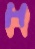

TotalCount :  38527
UNMATCHED, result :  N , label :  H
Remove Image Coutn :  2537
/mnt/d/linData/synth_asc7/train/tmp/154931.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


KeyboardInterrupt: 

In [15]:
ASC_data_filtering_mv('/mnt/d/linData/synth_asc7/train/flt.csv')
# ASC_data_filtering_mv('/mnt/d/linData/synth_asc2/train/flt.csv')
# ASC_data_filtering_mv('/mnt/d/linData/synth_asc5/train/flt.csv')
# ASC_data_filtering_mv('/mnt/d/linData/synth_asc6/train/flt.csv')
# ASC_data_filtering_mv('/mnt/d/linData/synth_asc7/train/flt.csv')

In [17]:
from IPython.display import clear_output
import os
import shutil

def ASC_data_filtering_mv_lb(csvFilePath, base_path):
    
    if (not os.path.isdir(base_path +"/split/")):
        os.mkdir(base_path +"/split/")
        
    for i in range(len(label2ASC) + 1):
        #print(base_path +"/split/" + label2ASC[i])
        #os.mkdir(base_path +"/split/" + label2ASC[i])
        if (not os.path.isdir(base_path +"/split/" + str(i))):
            os.mkdir(base_path +"/split/" + str(i))
    
    baseDir = os.path.dirname(csvFilePath)

    shufFile = "./shuffled.csv"
    cmdString = "shuf " + csvFilePath + " > " + shufFile
    
    #os.system("shuf /root/Data/hangul/dataset/ASC_train.csv > /root/Data/hangul/dataset/ASC_train_shuffle.csv")
    os.system(cmdString)
    
    csvFile = open(shufFile, 'r', encoding='utf-8')
    reader = csv.reader(csvFile)
    
    totalCnt = 0
    rmCnt = 0
    for line in reader:        
        imgFile = line[0]
        label = line[1]
        
        if not os.path.exists(imgFile):
            continue
        
        totalCnt += 1
        
        img = tf.io.read_file(imgFile)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.convert_image_dtype(img, tf.float32)
        img = tf.image.resize(img, (64, 64))
        
        img = np.array(img)
        img = np.expand_dims(img, axis=0)
        
        out = vit_classifier.predict(img)
        out = out.argmax()
        
        label_idx = int(label)
        
        if out != label_idx:
            
            if out > label_idx:
                max = out
                min = label_idx
            else:
                max = label_idx
                min = out
            
        
            split = os.path.split(imgFile)
            fileName = split[1]
            
            # if max == 0 | 24 | 50 // 0 o O continue;
            
            #dst = baseDir + "/split/" + label2ASC[label_idx] + "/" +fileName
            dst = baseDir + "/split/" + str(label_idx) + "/" +fileName
            
            clear_output()
                
            image = Image.open(imgFile)
            image.show()
                
            rmCnt +=1
            # print("imgFile : ", imgFile)
            print("TotalCount : ", totalCnt)
            print("UNMATCHED, result : ",label2ASC[out], ", label : ",label2ASC[label_idx])
            print("Remove Image Coutn : ", rmCnt)
                
            print("DST : ", dst)    
            shutil.move(imgFile, dst)
            
import shutil

def reloc_splited_data(src, dst, base_path):
    #file_list = os.listdir(src)
    
    for i in range(len(label2ASC)):
        curDir = base_path + "/split/" + str(i)
        file_list = os.listdir(curDir)
        for file in file_list:
            base_name = os.path.basename(file)
            file_name, file_extension = os.path.splitext(base_name)
            idx = int(file_name) // 10000
                
            outPath = dst + "/" + str(idx) + "/" + base_name
                
            shutil.move(curDir + "/" + file, outPath)
            #print("src : ", curDir + "/" + file, ", dst : ", outPath)
        


In [18]:
BASE = '/mnt/d/linData/synth_asc3/train'
BASE2 = '/mnt/d/linData/synth_asc6/train'

# 2 5 6 / 1 / 7 
# (7) 3 4 not yet
#ASC_data_filtering_mv_lb(BASE + '/flt.csv', BASE)
#ASC_data_filtering_mv_lb(BASE2 + '/flt.csv', BASE2)

reloc_splited_data(BASE + '/tmp', BASE + '/images', BASE)
#reloc_splited_data(BASE2 + '/tmp', BASE2 + '/images', BASE2)

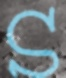

TotalCount :  184597
UNMATCHED, result :  C , label :  S
Remove Image Coutn :  22982
DST :  /mnt/d/linData/synth_asc4/train/split/28/63162.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


In [17]:
BASE3 = '/mnt/d/linData/synth_asc4/train'

ASC_data_filtering_mv_lb(BASE3 + '/flt.csv', BASE3)

In [19]:
import os
import shutil

def reloc(src, dst):
    file_list = os.listdir(src)
    
    for file in file_list:
        base_name = os.path.basename(file)
        file_name, file_extension = os.path.splitext(base_name)
        idx = int(file_name) // 10000
        
        outPath = dst + "/" + str(idx) + "/" + base_name
        
        
        #print(src + '/' + file, " to ", outPath)
        shutil.move(src + '/' + file, outPath)
        
BASE = '/mnt/d/linData/synth_asc2/train'
reloc(BASE + '/tmp', BASE + '/images')

In [ ]:
import threading

def Multi_filtering(targetList, name):
    print("")

CSV_targetList = []

ASC_data_filtering_mv('/mnt/d/linData/synth_asc1/train/flt.csv')

In [15]:
from IPython.display import clear_output

def testing():
    fileDir = '/root/Data/hangul_handwrite_val/image/ASC1'
    #fileDir = '/root/Data/hangul_handwrite_val/image/ASC2'
    files = os.listdir(fileDir)

    max = 100
    cnt = 0

    for file in files:
        if cnt > max:
            break
        
        cnt += 1
        
        clear_output()
        imageFile = fileDir + "/" +file
        print(imageFile)

        img = tf.io.read_file(imageFile)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.convert_image_dtype(img, tf.float32)
        img = tf.image.resize(img, (64, 64))

        print(img.shape)

        img = np.array(img)

        img = np.expand_dims(img, axis=0)

        #print(img.shape)

        out = vit_classifier.predict(img)
        
        #print(ch)

        out = out.argmax()
        
        print(label2ASC[out])

        image = Image.open(imageFile)
        image.show()
        
        str = ""
        input(str)
        #os.system('cls')
        
        if (str == "exit"):
            exit()

    
testing()

/root/Data/hangul_handwrite_val/image/ASC1/test58.jpg
(64, 64, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1


In [ ]:
#vit_classifier.load_weights(WEIGHT_FILE)
#vit_classifier.save('./vit_test.keras')
#vit_classifier.evaluate()

import tensorflow as tf
import tf2onnx
import onnx

import keras
from keras.models import Model



#input_signature = [tf.TensorSpec(shape = (None, 64, 64, 3), dtype =tf.float32, name = "posts")]
input_signature = [tf.TensorSpec(shape = (1, 64, 64, 3), dtype =tf.float32, name = "posts")]

#model = keras.models.load_model('./vit_test.keras')
# Use from_function for tf functions
onnx_model, _ = tf2onnx.convert.from_keras(vit_classifier, input_signature, opset=13)
onnx.save(onnx_model, "./model_8_2.onnx")

I0000 00:00:1724389045.978992  125508 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1724389045.979035  125508 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
2024-08-23 13:57:25.979170: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
I0000 00:00:1724389045.979496  125508 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1724389045.979533  125508 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1724389045.979556  125508 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been bui